# Multi-task fine-tuning (E9)

One encoder with **two regression heads**, trained on PHQ-9 and GAD-7 at once,
instead of one model per scale. Everything else matches the arms of notebook
05: question-level rows, layer-wise learning-rate decay, a cross-validated
epoch budget and a refit on all training participants, evaluation aggregated
per participant.

**Why it might help.** PHQ-9 and GAD-7 correlate at r = 0.82 in these
participants, and the single-task models' predictions for the two correlate at
0.97: the encoder is learning one shared notion of distress, twice. Training
against both doubles the supervised signal reaching it from the same 110
people, which is the scarce resource here, and regularizes the arm most
exposed to overfitting (PROTOCOL.md, Section 13).

**Why it might not.** The two heads compete for capacity, and a single epoch
budget has to serve both, so a scale that needed longer or shorter training
than the other loses out.

**What it is not.** No questionnaire is used to predict the other: both labels
are used only while training, and at prediction time the model sees text
alone, exactly like every other arm.

**Cost.** Half of the single-task arms: one training per fold instead of one
per scale.

**All metrics below are on the held-out test participants.** Cross-validation
numbers appear only where labelled, and come from training data alone.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
import warnings
from dataclasses import replace
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from src import config, data, splits, logging_utils
from src.multitask import run_multitask_cv_arm
from src.pipeline import TARGETS, build_train_frame, expand_to_questions
from src.plotting import plot_confusion_matrix, BAND_LABELS, SCREENING_LABELS

## Run configuration

In [2]:
# The finalists of the single-task comparison, plus BETO as the cheap
# control: if sharing one encoder between the two scales helps, it should
# help most where the encoder is smallest relative to the task.
ARMS = {
    "E9_E5LARGE_MT":         "intfloat/multilingual-e5-large",   # 560M / 303M enc
    "E9_ROBERTAES_MENTAL_MT": config.MENTAL_ES_MODEL,            # 355M / 303M enc
    "E9_E5BASE_MT":          "intfloat/multilingual-e5-base",    # 278M / 86M enc
    "E9_BETO_MT":            "dccuchile/bert-base-spanish-wwm-cased",   # 110M / 86M enc
}

# Each arm's single-task counterpart in the fine-tuning-cv family, which is
# what it is compared against: same checkpoint, same recipe, same folds, one
# model per scale instead of one for both.
COUNTERPARTS = {
    "E9_E5LARGE_MT": "E5_E5LARGE_FT",
    "E9_ROBERTAES_MENTAL_MT": "E8_ROBERTAES_MENTAL_FT",
    "E9_E5BASE_MT": "E5_E5BASE_FT",
    "E9_BETO_MT": "E5_BETO_FT",
}

cfg = config.FineTuningCVConfig(
    # Must match the fine-tuning-cv runs this is compared with.
    augmentation=config.AUGMENTATION_NONE,   # <- AUGMENTATION_NONE  AUGMENTATION_LLM
    seeds=(42,),
    n_cv_splits=5,
    max_epochs=20,
    patience=4,
    batch_size=16,
    grad_accum_steps=1,
    max_tokens=512,
    lr_head=1e-4,
    lr_encoder_top=3e-5,
    llrd_decay=0.9,
    warmup_ratio=0.10,
    use_bf16=True,
)

# Same escape hatch as notebooks 04 and 05, for an arm that runs out of memory.
OVERRIDES = {}

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"device: {torch.cuda.get_device_name(0)}  |  VRAM free {free/1e9:.1f} / {total/1e9:.1f} GB")
else:
    print("WARNING: no CUDA device; fine-tuning on CPU is impractical here")
print(f"{cfg.n_cv_splits} folds + 1 refit = {cfg.n_cv_splits + 1} trainings per arm, "
      f"covering both scales (half of what the single-task arms cost)")
cfg

device: NVIDIA GeForce RTX 4060 Ti  |  VRAM free 16.0 / 17.2 GB
5 folds + 1 refit = 6 trainings per arm, covering both scales (half of what the single-task arms cost)


FineTuningCVConfig(augmentation='no_augmentation', seeds=(42,), max_epochs=20, patience=4, batch_size=16, eval_batch_size=32, grad_accum_steps=1, max_tokens=512, lr_head=0.0001, lr_encoder_top=3e-05, llrd_decay=0.9, weight_decay=0.01, warmup_ratio=0.1, max_grad_norm=1.0, val_fraction=0.2, use_bf16=True, n_cv_splits=5)

In [3]:
df = data.load_dataset()
train_ids, test_ids = splits.train_test_participants(df)
train_frame, aug_groups = build_train_frame(df, train_ids, test_ids, config.TrainingConfig(
    augmentation=cfg.augmentation))
test_frame = df.loc[test_ids]

group_col = "original_participant" if aug_groups is not None else None
q_train = expand_to_questions(train_frame, group_col=group_col)
q_test = expand_to_questions(test_frame)

groups = q_train["group"].to_numpy()
test_groups = q_test["participant"].to_numpy()
N_TEST = len(test_frame)

print(f"train: {len(train_frame)} rows -> {len(q_train)} question rows, "
      f"{len(np.unique(groups))} people")
print(f"test:  {N_TEST} participants -> {len(q_test)} question rows "
      f"(evaluated per participant)")

train: 110 rows -> 376 question rows, 110 people
test:  48 participants -> 168 question rows (evaluated per participant)


Fold sizes, before running anything. Every fold must keep all of a
person's answers on one side; the check below is the same guarantee the
frozen notebooks rely on.

In [4]:
splitter = splits.cv_splitter(groups=groups, n_splits=cfg.n_cv_splits,
                               random_state=cfg.seeds[0])
folds = list(splitter.split(q_train["text"].to_numpy(),
                             splits.stratify_key(q_train), groups=groups))

rows = []
for k, (fit_idx, val_idx) in enumerate(folds, start=1):
    fit_people, val_people = set(groups[fit_idx]), set(groups[val_idx])
    rows.append({"fold": k, "fit_rows": len(fit_idx), "fit_people": len(fit_people),
                  "val_rows": len(val_idx), "val_people": len(val_people),
                  "people_overlap": len(fit_people & val_people)})
display(pd.DataFrame(rows))
assert all(r["people_overlap"] == 0 for r in rows), "a participant spans two folds"
print("Every training participant is scored out of fold exactly once, and no "
      "participant appears on both sides of any fold.")

,fold,fit_rows,fit_people,val_rows,val_people,people_overlap
0,1,298,88,78,22,0
1,2,301,88,75,22,0
2,3,304,89,72,21,0
3,4,300,87,76,23,0
4,5,301,88,75,22,0


Every training participant is scored out of fold exactly once, and no participant appears on both sides of any fold.


In [5]:
def report_arm(arm, run_rows):
    runs = pd.DataFrame(run_rows)
    params = list(runs["selected_params"])

    print(f"[TEST] {arm}: RMSE / MAE / R2 on the {N_TEST} held-out participants, "
          f"both scales read from one model")
    display(runs.pivot(index="seed", columns="target", values=["rmse", "mae", "r2"]).round(3))

    print("[CROSS-VALIDATION on training data] out-of-fold RMSE per scale, and the "
          "shared epoch budget the folds chose. This is not a test score.")
    display(pd.DataFrame({
        "target": runs["target"],
        "seed": runs["seed"],
        "cv_rmse": [p["cv_rmse"] for p in params],
        "cv_r2": [p["cv_r2"] for p in params],
        "fold_epochs": [p["fold_epochs"] for p in params],
        "refit_epochs": [p["refit_epochs"] for p in params],
    }).set_index(["target", "seed"]))

    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    for i, target in enumerate(TARGETS):
        target_runs = runs[runs["target"] == target]
        best = target_runs.loc[target_runs["rmse"].idxmin()]
        seed = int(best["seed"])
        plot_confusion_matrix(axes[i, 0], best["band_confusion_matrix"], BAND_LABELS,
                                f"{target} severity bands (seed={seed})")
        plot_confusion_matrix(axes[i, 1], best["screening_confusion_matrix"], SCREENING_LABELS,
                                f"{target} screening, cutoff 10 (seed={seed})")
    plt.suptitle(f"[TEST] {arm}: derived from the same continuous prediction")
    plt.tight_layout()
    plt.show()


def train_and_report(arm):
    arm_cfg = replace(cfg, **OVERRIDES.get(arm, {}))
    t0 = time.time()
    rows = run_multitask_cv_arm(arm, ARMS[arm], q_train, q_test, groups, test_groups,
                                 arm_cfg, device)
    print(f"{arm} done in {(time.time()-t0)/60:.1f} min")
    report_arm(arm, rows)

## Arms

Ordered cheapest first. Each cell is independent: a run logs its own rows, so
an arm can be re-run or skipped without disturbing the others.

### BETO, multi-task

The smallest encoder here, and the one with the most to gain if sharing helps:
110M parameters against a few hundred training rows. Its counterpart is
`E5_BETO_FT` in the fine-tuning-cv family.

  E9_BETO_MT seed=42 targets=PHQ9+GAD7: 5 folds + refit
   fold 1/5  fit 298 rows / 88 people


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 28036.98it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differe

    epoch  1  val_rmse(scaled) mean 1.1509  [PHQ9 1.0808  GAD7 1.2210]  *
    epoch  2  val_rmse(scaled) mean 1.1340  [PHQ9 1.0941  GAD7 1.1739]  *
    epoch  3  val_rmse(scaled) mean 1.1945  [PHQ9 1.2156  GAD7 1.1733]
    epoch  4  val_rmse(scaled) mean 1.1514  [PHQ9 1.0648  GAD7 1.2380]
    epoch  5  val_rmse(scaled) mean 1.0814  [PHQ9 0.9576  GAD7 1.2052]  *
    epoch  6  val_rmse(scaled) mean 1.0781  [PHQ9 0.9961  GAD7 1.1601]  *
    epoch  7  val_rmse(scaled) mean 1.0327  [PHQ9 0.9559  GAD7 1.1094]  *
    epoch  8  val_rmse(scaled) mean 1.0268  [PHQ9 0.9230  GAD7 1.1306]  *
    epoch  9  val_rmse(scaled) mean 1.0328  [PHQ9 0.9508  GAD7 1.1148]
    epoch 10  val_rmse(scaled) mean 1.0255  [PHQ9 0.9217  GAD7 1.1292]  *
    epoch 11  val_rmse(scaled) mean 1.0460  [PHQ9 0.9124  GAD7 1.1795]
    epoch 12  val_rmse(scaled) mean 1.0185  [PHQ9 0.9340  GAD7 1.1030]  *
    epoch 13  val_rmse(scaled) mean 1.0429  [PHQ9 0.9489  GAD7 1.1370]
    epoch 14  val_rmse(scaled) mean 1.0055  [PHQ9 0.9

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 13547.76it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differe

    epoch  1  val_rmse(scaled) mean 0.8568  [PHQ9 0.8168  GAD7 0.8968]  *
    epoch  2  val_rmse(scaled) mean 0.8152  [PHQ9 0.7670  GAD7 0.8635]  *
    epoch  3  val_rmse(scaled) mean 0.8715  [PHQ9 0.7748  GAD7 0.9682]
    epoch  4  val_rmse(scaled) mean 0.8961  [PHQ9 0.7846  GAD7 1.0077]
    epoch  5  val_rmse(scaled) mean 0.8387  [PHQ9 0.8226  GAD7 0.8549]
    epoch  6  val_rmse(scaled) mean 0.8520  [PHQ9 0.8085  GAD7 0.8955]
   fold 3/5  fit 304 rows / 89 people


...

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 33306.91it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differe

    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    epoch  3  (refit, no early stopping)
    epoch  4  (refit, no early stopping)
    -> PHQ9: [CV] rmse 4.940   [TEST] rmse 4.345  mae 3.734  r2 0.375
    -> GAD7: [CV] rmse 4.336   [TEST] rmse 4.359  mae 3.380  r2 0.249
    (4.3 min for both scales)
E9_BETO_MT done in 4.3 min
[TEST] E9_BETO_MT: RMSE / MAE / R2 on the 48 held-out participants, both scales read from one model


rmse          mae            r2       
target   GAD7   PHQ9  GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.359  4.345  3.38  3.734  0.249  0.375

[CROSS-VALIDATION on training data] out-of-fold RMSE per scale, and the shared epoch budget the folds chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,4.9398,0.3117,"[14, 2, 5, 4, 3]",4
GAD7,42,4.3357,0.2327,"[14, 2, 5, 4, 3]",4


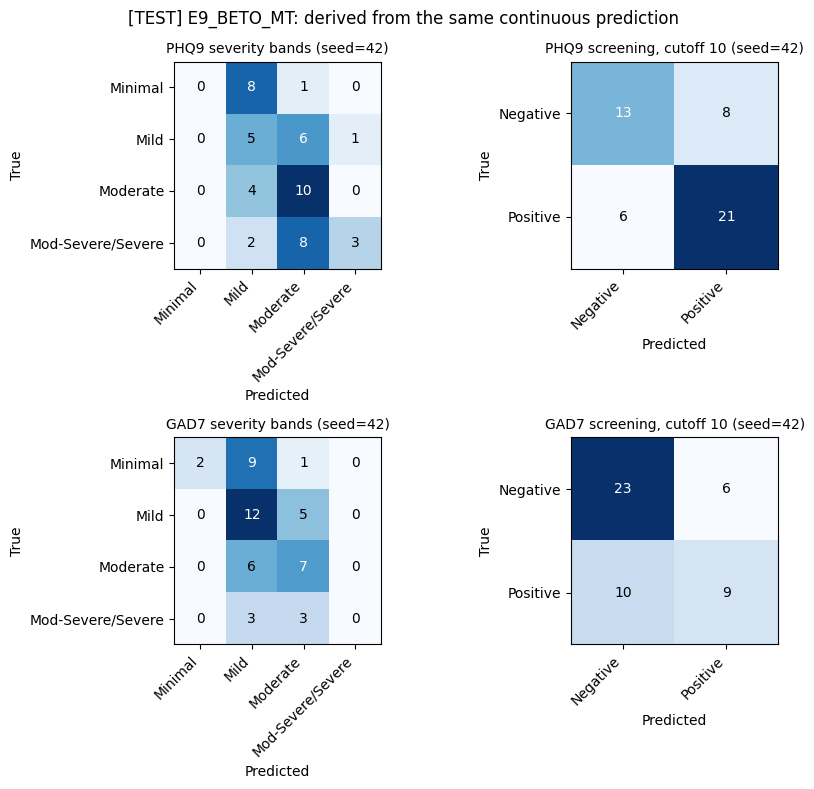

In [6]:
train_and_report("E9_BETO_MT")

### e5-base, multi-task

Counterpart: `E5_E5BASE_FT`.

  E9_E5BASE_MT seed=42 targets=PHQ9+GAD7: 5 folds + refit
   fold 1/5  fit 298 rows / 88 people


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4582.41it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) mean 1.1476  [PHQ9 1.1026  GAD7 1.1927]  *
    epoch  2  val_rmse(scaled) mean 1.1442  [PHQ9 1.1159  GAD7 1.1724]  *
    epoch  3  val_rmse(scaled) mean 1.2210  [PHQ9 1.2534  GAD7 1.1887]
    epoch  4  val_rmse(scaled) mean 1.0377  [PHQ9 1.0054  GAD7 1.0700]  *
    epoch  5  val_rmse(scaled) mean 0.9993  [PHQ9 0.9359  GAD7 1.0627]  *
    epoch  6  val_rmse(scaled) mean 1.0216  [PHQ9 0.9220  GAD7 1.1212]
    epoch  7  val_rmse(scaled) mean 1.0245  [PHQ9 0.9599  GAD7 1.0891]
    epoch  8  val_rmse(scaled) mean 1.0514  [PHQ9 1.0180  GAD7 1.0848]
    epoch  9  val_rmse(scaled) mean 1.1191  [PHQ9 1.0540  GAD7 1.1843]
   fold 2/5  fit 301 rows / 88 people


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 9532.51it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) mean 0.8929  [PHQ9 0.8118  GAD7 0.9740]  *
    epoch  2  val_rmse(scaled) mean 0.9250  [PHQ9 0.8674  GAD7 0.9826]
    epoch  3  val_rmse(scaled) mean 0.7456  [PHQ9 0.6433  GAD7 0.8480]  *
    epoch  4  val_rmse(scaled) mean 0.7836  [PHQ9 0.7710  GAD7 0.7961]
    epoch  5  val_rmse(scaled) mean 0.7469  [PHQ9 0.7066  GAD7 0.7872]
    epoch  6  val_rmse(scaled) mean 0.7469  [PHQ9 0.7021  GAD7 0.7917]
    epoch  7  val_rmse(scaled) mean 0.8023  [PHQ9 0.7794  GAD7 0.8251]
   fold 3/5  fit 304 rows / 89 people


...

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 10071.40it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    epoch  3  (refit, no early stopping)
    epoch  4  (refit, no early stopping)
    -> PHQ9: [CV] rmse 4.896   [TEST] rmse 4.318  mae 3.537  r2 0.382
    -> GAD7: [CV] rmse 4.341   [TEST] rmse 4.241  mae 3.321  r2 0.289
    (4.8 min for both scales)
E9_E5BASE_MT done in 4.8 min
[TEST] E9_E5BASE_MT: RMSE / MAE / R2 on the 48 held-out participants, both scales read from one model


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.241  4.318  3.321  3.537  0.289  0.382

[CROSS-VALIDATION on training data] out-of-fold RMSE per scale, and the shared epoch budget the folds chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,4.8957,0.3239,"[5, 3, 4, 4, 2]",4
GAD7,42,4.3407,0.2309,"[5, 3, 4, 4, 2]",4


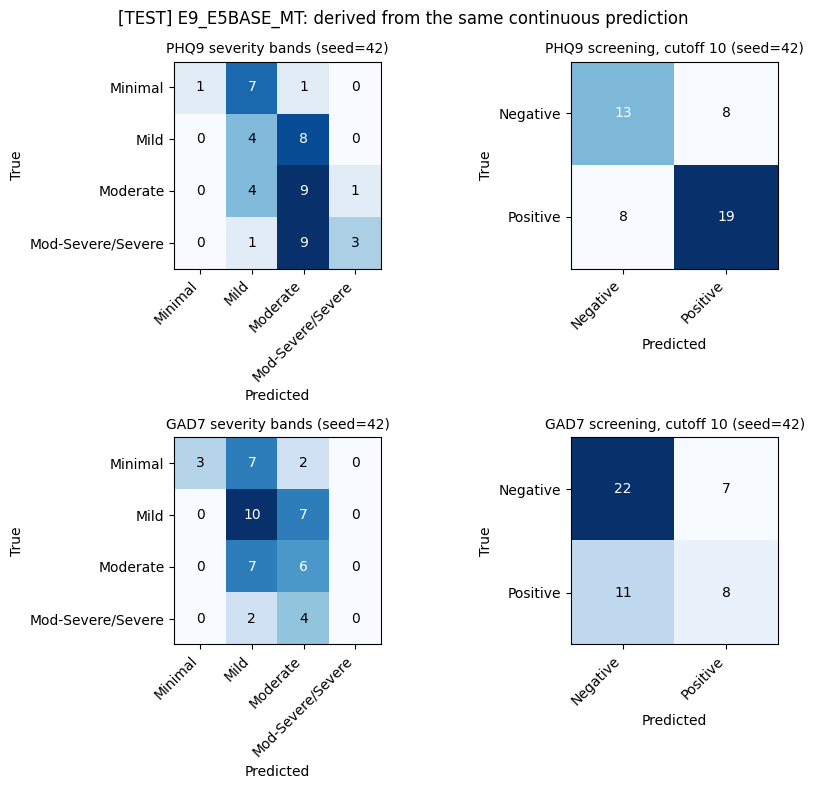

In [7]:
train_and_report("E9_E5BASE_MT")

### RoBERTa-es-mental, multi-task

The domain-adapted Spanish model, whose single-task run was the strongest of
the adapted arms. Counterpart: `E8_ROBERTAES_MENTAL_FT`. At 355M parameters
and six trainings, budget over an hour.

  E9_ROBERTAES_MENTAL_MT seed=42 targets=PHQ9+GAD7: 5 folds + refit
   fold 1/5  fit 298 rows / 88 people


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4805.52it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: ELiRF/RoBERTa-es-mental-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) mean 1.1601  [PHQ9 1.1319  GAD7 1.1884]  *
    epoch  2  val_rmse(scaled) mean 1.0492  [PHQ9 1.0838  GAD7 1.0147]  *
    epoch  3  val_rmse(scaled) mean 1.1171  [PHQ9 1.0253  GAD7 1.2088]
    epoch  4  val_rmse(scaled) mean 0.9747  [PHQ9 0.9067  GAD7 1.0428]  *
    epoch  5  val_rmse(scaled) mean 0.9841  [PHQ9 0.9221  GAD7 1.0460]
    epoch  6  val_rmse(scaled) mean 1.0339  [PHQ9 0.8961  GAD7 1.1717]
    epoch  7  val_rmse(scaled) mean 0.9684  [PHQ9 0.8999  GAD7 1.0370]  *
    epoch  8  val_rmse(scaled) mean 0.9933  [PHQ9 0.9244  GAD7 1.0622]
    epoch  9  val_rmse(scaled) mean 1.0231  [PHQ9 0.9699  GAD7 1.0763]
    epoch 10  val_rmse(scaled) mean 0.9875  [PHQ9 0.9231  GAD7 1.0520]
    epoch 11  val_rmse(scaled) mean 1.0118  [PHQ9 0.9541  GAD7 1.0696]
   fold 2/5  fit 301 rows / 88 people


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 9444.55it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: ELiRF/RoBERTa-es-mental-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) mean 0.8530  [PHQ9 0.7946  GAD7 0.9113]  *
    epoch  2  val_rmse(scaled) mean 0.7500  [PHQ9 0.7123  GAD7 0.7877]  *
    epoch  3  val_rmse(scaled) mean 0.7827  [PHQ9 0.7637  GAD7 0.8016]
    epoch  4  val_rmse(scaled) mean 0.7970  [PHQ9 0.7988  GAD7 0.7951]
    epoch  5  val_rmse(scaled) mean 0.7934  [PHQ9 0.7953  GAD7 0.7914]
    epoch  6  val_rmse(scaled) mean 0.7531  [PHQ9 0.7172  GAD7 0.7890]
   fold 3/5  fit 304 rows / 89 people


...

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 8188.46it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: ELiRF/RoBERTa-es-mental-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    epoch  3  (refit, no early stopping)
    epoch  4  (refit, no early stopping)
    -> PHQ9: [CV] rmse 4.775   [TEST] rmse 4.378  mae 3.703  r2 0.365
    -> GAD7: [CV] rmse 4.191   [TEST] rmse 4.204  mae 3.269  r2 0.302
    (16.7 min for both scales)
E9_ROBERTAES_MENTAL_MT done in 16.7 min
[TEST] E9_ROBERTAES_MENTAL_MT: RMSE / MAE / R2 on the 48 held-out participants, both scales read from one model


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.204  4.378  3.269  3.703  0.302  0.365

[CROSS-VALIDATION on training data] out-of-fold RMSE per scale, and the shared epoch budget the folds chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,4.7747,0.3569,"[7, 2, 6, 4, 2]",4
GAD7,42,4.1912,0.2830,"[7, 2, 6, 4, 2]",4


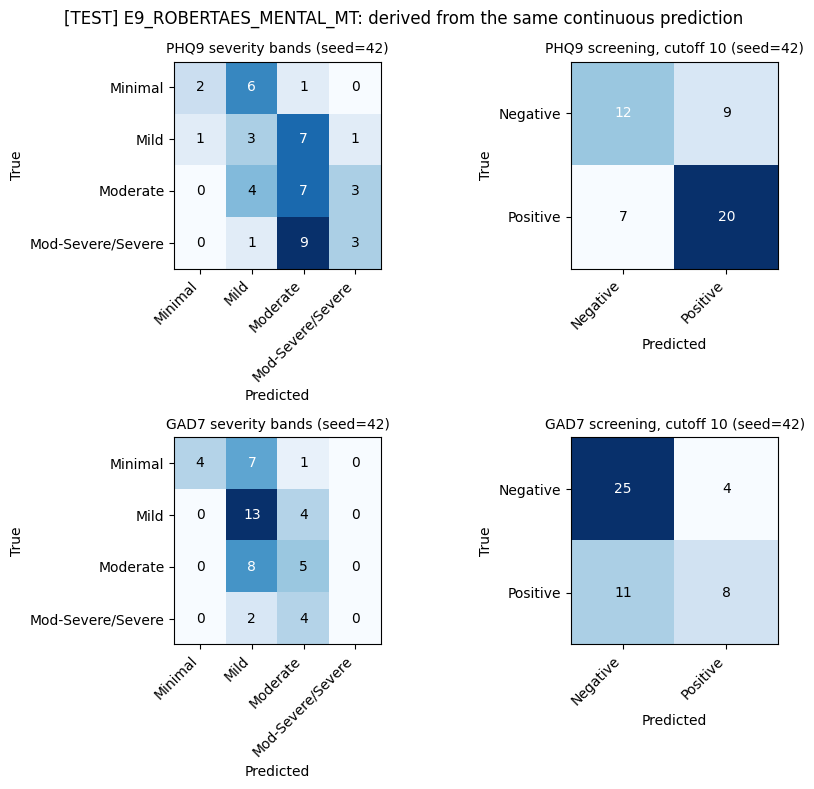

In [8]:
train_and_report("E9_ROBERTAES_MENTAL_MT")

### e5-large, multi-task

The best single-task arm on both scales, and the most expensive one here.
Counterpart: `E5_E5LARGE_FT`.

  E9_E5LARGE_MT seed=42 targets=PHQ9+GAD7: 5 folds + refit
   fold 1/5  fit 298 rows / 88 people


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 2493.26it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-large
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) mean 1.1104  [PHQ9 1.0601  GAD7 1.1608]  *
    epoch  2  val_rmse(scaled) mean 1.0530  [PHQ9 0.9961  GAD7 1.1099]  *
    epoch  3  val_rmse(scaled) mean 1.1244  [PHQ9 1.0724  GAD7 1.1764]
    epoch  4  val_rmse(scaled) mean 0.9965  [PHQ9 0.9501  GAD7 1.0430]  *
    epoch  5  val_rmse(scaled) mean 1.0017  [PHQ9 0.9357  GAD7 1.0676]
    epoch  6  val_rmse(scaled) mean 1.1256  [PHQ9 0.9966  GAD7 1.2546]
    epoch  7  val_rmse(scaled) mean 1.0182  [PHQ9 0.9302  GAD7 1.1062]
    epoch  8  val_rmse(scaled) mean 1.0957  [PHQ9 1.0160  GAD7 1.1755]
   fold 2/5  fit 301 rows / 88 people


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 5669.14it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-large
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) mean 0.8229  [PHQ9 0.8109  GAD7 0.8349]  *
    epoch  2  val_rmse(scaled) mean 0.7326  [PHQ9 0.6685  GAD7 0.7967]  *
    epoch  3  val_rmse(scaled) mean 0.8979  [PHQ9 0.7800  GAD7 1.0159]
    epoch  4  val_rmse(scaled) mean 0.9081  [PHQ9 0.7643  GAD7 1.0519]
    epoch  5  val_rmse(scaled) mean 0.8997  [PHQ9 0.7729  GAD7 1.0265]
    epoch  6  val_rmse(scaled) mean 0.7355  [PHQ9 0.7212  GAD7 0.7497]
   fold 3/5  fit 304 rows / 89 people


...

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 10641.90it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-large
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    epoch  3  (refit, no early stopping)
    -> PHQ9: [CV] rmse 4.749   [TEST] rmse 4.448  mae 3.638  r2 0.345
    -> GAD7: [CV] rmse 4.122   [TEST] rmse 4.157  mae 3.076  r2 0.317
    (75.0 min for both scales)
E9_E5LARGE_MT done in 75.0 min
[TEST] E9_E5LARGE_MT: RMSE / MAE / R2 on the 48 held-out participants, both scales read from one model


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.157  4.448  3.076  3.638  0.317  0.345

[CROSS-VALIDATION on training data] out-of-fold RMSE per scale, and the shared epoch budget the folds chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,4.7485,0.3640,"[4, 2, 5, 3, 2]",3
GAD7,42,4.1220,0.3065,"[4, 2, 5, 3, 2]",3


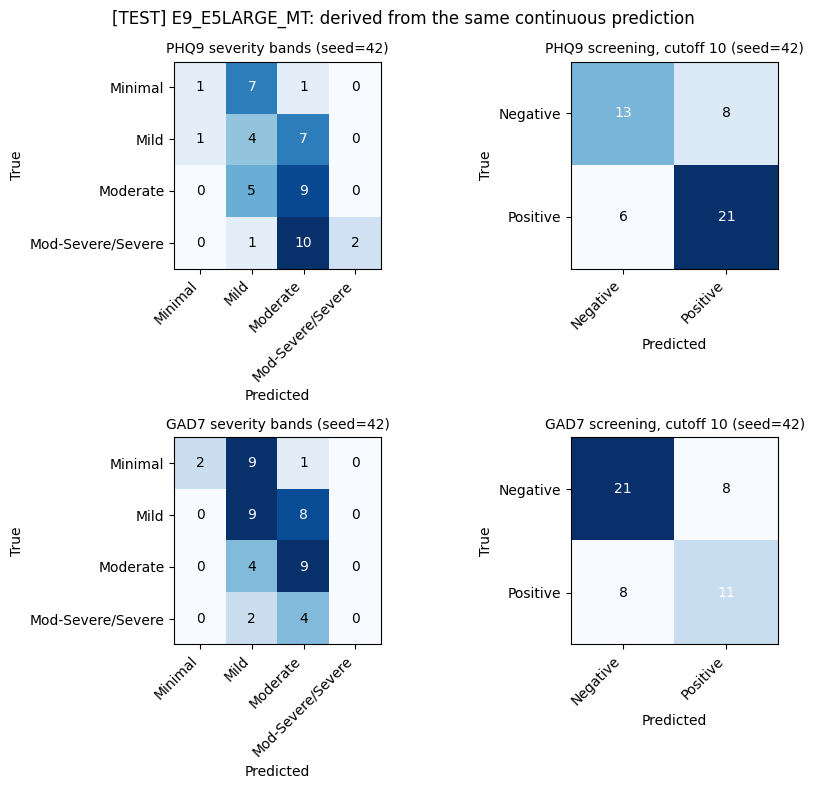

In [9]:
train_and_report("E9_E5LARGE_MT")

## Multi-task against single-task

Each arm against the same checkpoint trained one scale at a time, under the
same folds and the same recipe.

In [10]:
log = logging_utils.load_all_runs()
log = log[(log.augmentation == cfg.augmentation)
           & log.family.isin([config.FAMILY_FINETUNING_MT, config.FAMILY_FINETUNING_CV])]

pairs = [(mt, single) for mt, single in COUNTERPARTS.items()
         if mt in set(log.encoder) and single in set(log.encoder)]
rows = []
for mt, single in pairs:
    for target in TARGETS:
        a = log[(log.encoder == mt) & (log.target == target)]
        b = log[(log.encoder == single) & (log.target == target)
                 & (log.family == config.FAMILY_FINETUNING_CV)]
        if a.empty or b.empty:
            continue
        rows.append({"arm": mt, "target": target,
                     "multitask_rmse": a.rmse.mean(), "single_task_rmse": b.rmse.mean(),
                     "difference": a.rmse.mean() - b.rmse.mean(),
                     "multitask_r2": a.r2.mean(), "single_task_r2": b.r2.mean()})
print(f"[TEST] RMSE on the {N_TEST} held-out participants. Negative difference "
      f"means the shared encoder won.")
display(pd.DataFrame(rows).set_index(["arm", "target"]).round(3))

[TEST] RMSE on the 48 held-out participants. Negative difference means the shared encoder won.


multitask_rmse  single_task_rmse  difference  \
arm                    target                                                 
E9_E5LARGE_MT          PHQ9             4.448             4.394       0.055   
                       GAD7             4.157             4.059       0.098   
E9_ROBERTAES_MENTAL_MT PHQ9             4.378             4.350       0.028   
                       GAD7             4.204             4.228      -0.024   
E9_E5BASE_MT           PHQ9             4.318             4.501      -0.183   
                       GAD7             4.241             4.277      -0.036   
E9_BETO_MT             PHQ9             4.345             4.444      -0.098   
                       GAD7             4.359             4.309       0.050   

                               multitask_r2  single_task_r2  
arm                    target                                
E9_E5LARGE_MT          PHQ9           0.345           0.361  
                       GAD7           0.317           0.349  
E9_ROBERTAES_MENTAL_MT PHQ9           0.365           0.373  
                       GAD7           0.302           0.294  
E9_E5BASE_MT           PHQ9           0.382           0.329  
                       GAD7           0.289           0.277  
E9_BETO_MT             PHQ9           0.375           0.346  
                       GAD7           0.249           0.266

### Paired comparison

Per-participant squared-error difference with a paired bootstrap 95% CI and a
Wilcoxon signed-rank test, Holm-corrected within each scale across the arms
(PROTOCOL.md, Section 10). Negative means the shared encoder won.

In [11]:
from src import metrics

run_dir = config.results_dir(cfg.augmentation, config.FAMILY_FINETUNING_MT,
                              config.GRANULARITY_QUESTION)
single_dir = config.results_dir(cfg.augmentation, config.FAMILY_FINETUNING_CV,
                                 config.GRANULARITY_QUESTION)
seed = cfg.seeds[0]


def load(directory, arm, target, label):
    path = directory / "predictions" / f"{arm}__{target}__{seed}__{label}.csv"
    return pd.read_csv(path).set_index("participant")


for target in TARGETS:
    rows, p_values = [], {}
    for mt, single in COUNTERPARTS.items():
        try:
            a = load(run_dir, mt, target, "finetuned_mt_cv")
            b = load(single_dir, single, target, "finetuned_cv").loc[a.index]
        except FileNotFoundError:
            continue
        result = metrics.paired_comparison(a.y_true.to_numpy(), a.y_pred.to_numpy(),
                                           b.y_pred.to_numpy())
        p_values[mt] = result["squared_error_wilcoxon_p"]
        rows.append({"arm": mt, "vs": single,
                     "d_sq_error": result["squared_error_diff_mean"],
                     "ci95_low": result["squared_error_diff_ci95"][0],
                     "ci95_high": result["squared_error_diff_ci95"][1],
                     "wilcoxon_p": result["squared_error_wilcoxon_p"],
                     "d_abs_error": result["absolute_error_diff_mean"]})
    if not rows:
        continue
    holm = metrics.holm_bonferroni(p_values)
    table = pd.DataFrame(rows).set_index("arm")
    table["holm_significant"] = [holm[arm]["significant"] for arm in table.index]
    print(f"[TEST] {target}: multi-task minus its single-task counterpart, "
          f"n={len(a)} (negative = multi-task better)")
    display(table.round(3))

[TEST] PHQ9: multi-task minus its single-task counterpart, n=48 (negative = multi-task better)


,vs,d_sq_error,ci95_low,ci95_high,wilcoxon_p,d_abs_error,holm_significant
arm,,,,,,,
E9_E5LARGE_MT,E5_E5LARGE_FT,0.482,-3.593,4.490,0.749,0.049,False
E9_ROBERTAES_MENTAL_MT,E8_ROBERTAES_MENTAL_FT,0.243,-1.242,1.641,0.955,0.043,False
E9_E5BASE_MT,E5_E5BASE_FT,-1.614,-4.189,0.661,0.545,-0.207,False
E9_BETO_MT,E5_BETO_FT,-0.865,-2.682,0.826,0.412,-0.112,False


[TEST] GAD7: multi-task minus its single-task counterpart, n=48 (negative = multi-task better)


,vs,d_sq_error,ci95_low,ci95_high,wilcoxon_p,d_abs_error,holm_significant
arm,,,,,,,
E9_E5LARGE_MT,E5_E5LARGE_FT,0.809,-0.904,2.632,0.179,0.124,False
E9_ROBERTAES_MENTAL_MT,E8_ROBERTAES_MENTAL_FT,-0.206,-1.308,0.834,0.696,0.001,False
E9_E5BASE_MT,E5_E5BASE_FT,-0.308,-2.150,1.484,0.367,-0.143,False
E9_BETO_MT,E5_BETO_FT,0.430,-2.651,3.822,0.538,-0.088,False
